# qrc-engine Evaluation

Full benchmark of all backends and all evolution modes — including the new **projective measurement / wavefunction collapse** features — on three tasks:

- **Mackey-Glass** (chaotic 1-D forecasting)
- **NARMA-10** (nonlinear memory, order 10)
- **Lorenz** (3-D multivariate input)

Metric: **NRMSE** (lower is better; > 1.0 = worse than predicting the mean).

In [1]:
import warnings
import time
import matplotlib.pyplot as plt
import numpy as np

from qrc_engine import Reservoir
from qrc_engine.backends import DynamiqsBackend, PercevalBackend, QiskitBackend
from qrc_engine.tasks import lorenz_system, mackey_glass, narma10
from qrc_engine.utils import nrmse

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
WASHOUT = 50

def run_config(label, backend, alpha, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    res = Reservoir(backend=backend, washout=WASHOUT, alpha=alpha)
    res.fit(X_tr, y_tr)
    pred = res.predict(X_te)
    elapsed = time.perf_counter() - t0
    score = nrmse(y_te[WASHOUT:], pred)
    return label, score, pred, elapsed

In [2]:
X_mg_tr, y_mg_tr, X_mg_te, y_mg_te = mackey_glass(n_samples=2000, split=0.8, seed=11)
X_nm_tr, y_nm_tr, X_nm_te, y_nm_te = narma10(n_samples=2000, split=0.8, seed=11)
X_lz_tr, y_lz_tr, X_lz_te, y_lz_te = lorenz_system(n_samples=2000, split=0.8, seed=7)
print('Tasks loaded.')

Tasks loaded.


## QiskitBackend — All Modes on Mackey-Glass

Four modes: stateless rebuild, persistent statevector, persistent + **full projective collapse**, persistent + **partial collapse** (2 of 4 qubits measured).

  Default (rebuild each step): NRMSE=0.0708 (5.9s)
  Persistent (no collapse): NRMSE=1.0127 (5.9s)
  Persistent + full collapse: NRMSE=1.0035 (6.6s)
  Persistent + partial (2/4): NRMSE=0.9998 (6.8s)


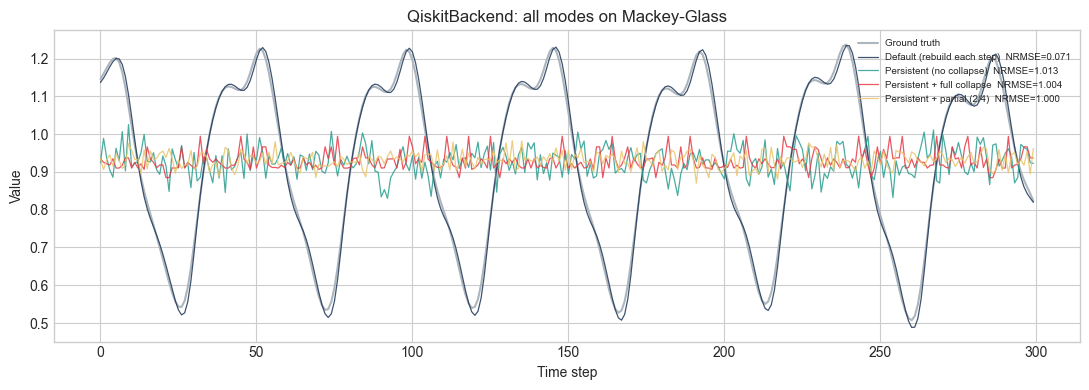

In [3]:
qk_mg = []
qk_mg.append(run_config('Default (rebuild each step)',
    QiskitBackend(n_qubits=4, depth=4, seed=11), 1e-3,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
qk_mg.append(run_config('Persistent (no collapse)',
    QiskitBackend(n_qubits=4, depth=4, persistent_state=True, seed=11), 1e-3,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
qk_mg.append(run_config('Persistent + full collapse',
    QiskitBackend(n_qubits=4, depth=4, persistent_state=True,
                  measure_and_collapse=True, seed=11), 1e-3,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
qk_mg.append(run_config('Persistent + partial (2/4)',
    QiskitBackend(n_qubits=4, depth=4, persistent_state=True,
                  measure_and_collapse=True, n_measured_qubits=2, seed=11), 1e-3,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))

for l, s, _, t in qk_mg:
    print(f'  {l}: NRMSE={s:.4f} ({t:.1f}s)')

fig, ax = plt.subplots(figsize=(11, 4))
ground = y_mg_te[WASHOUT:]
ax.plot(ground[:300], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip(qk_mg, ['#1d3557', '#2a9d8f', '#e63946', '#e9c46a']):
    ax.plot(p[:300], label=f'{l}  NRMSE={s:.3f}', lw=0.9, color=c, alpha=0.85)
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('QiskitBackend: all modes on Mackey-Glass')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout(); plt.show()

## PercevalBackend — All Modes on Mackey-Glass

Four modes: classical field, Fock analytic, Fock + **threshold detection** (sampled click statistics), Fock + feedback.

  Classical field: NRMSE=0.8289 (0.5s)
  Fock (analytic): NRMSE=0.9929 (19.3s)
  Fock + threshold det.: NRMSE=0.5438 (35.5s)
  Fock + feedback: NRMSE=0.1106 (18.6s)


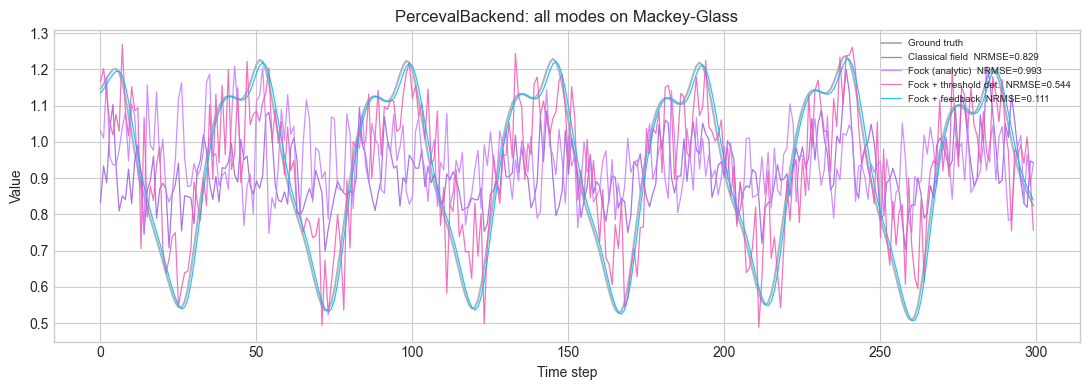

In [4]:
pcv_mg = []
pcv_mg.append(run_config('Classical field',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, memory_decay=0.95, seed=3), 1e-4,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
pcv_mg.append(run_config('Fock (analytic)',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    memory_decay=0.7, seed=3), 1e-4,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
pcv_mg.append(run_config('Fock + threshold det.',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    threshold_detection=True, memory_decay=0.7,
                    n_detection_samples=2000, seed=3), 1e-4,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
pcv_mg.append(run_config('Fock + feedback',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    feedback=True, memory_decay=0.7, seed=3), 1e-4,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))

for l, s, _, t in pcv_mg:
    print(f'  {l}: NRMSE={s:.4f} ({t:.1f}s)')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ground[:300], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip(pcv_mg, ['#9b5de5', '#c77dff', '#f15bb5', '#00bbf9']):
    ax.plot(p[:300], label=f'{l}  NRMSE={s:.3f}', lw=0.9, color=c, alpha=0.85)
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('PercevalBackend: all modes on Mackey-Glass')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout(); plt.show()

## DynamiqsBackend — All Modes on Mackey-Glass

Three modes: convex-mixture dissipation, Lindblad master equation, mixture + **projective measurement collapse**.

  Convex mixture: NRMSE=0.2323 (0.2s)
  Lindblad: NRMSE=0.6222 (1.0s)
  Mixture + collapse: NRMSE=0.2323 (0.2s)


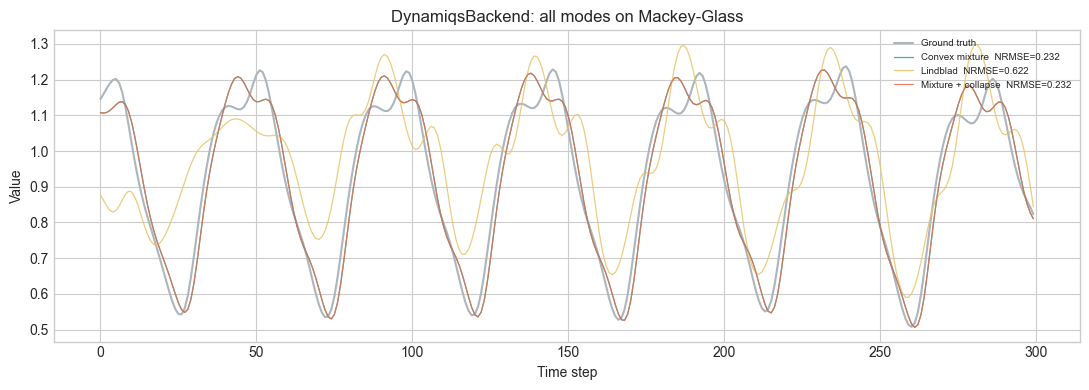

In [5]:
dq_mg = []
dq_mg.append(run_config('Convex mixture',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1, seed=3), 1e-5,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
dq_mg.append(run_config('Lindblad',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1, lindblad=True, seed=3), 1e-5,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))
dq_mg.append(run_config('Mixture + collapse',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1,
                    projective_measurement=True, seed=3), 1e-5,
    X_mg_tr, y_mg_tr, X_mg_te, y_mg_te))

for l, s, _, t in dq_mg:
    print(f'  {l}: NRMSE={s:.4f} ({t:.1f}s)')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ground[:300], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip(dq_mg, ['#2a9d8f', '#e9c46a', '#e76f51']):
    ax.plot(p[:300], label=f'{l}  NRMSE={s:.3f}', lw=0.9, color=c, alpha=0.85)
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.set_title('DynamiqsBackend: all modes on Mackey-Glass')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout(); plt.show()

## Mackey-Glass Summary

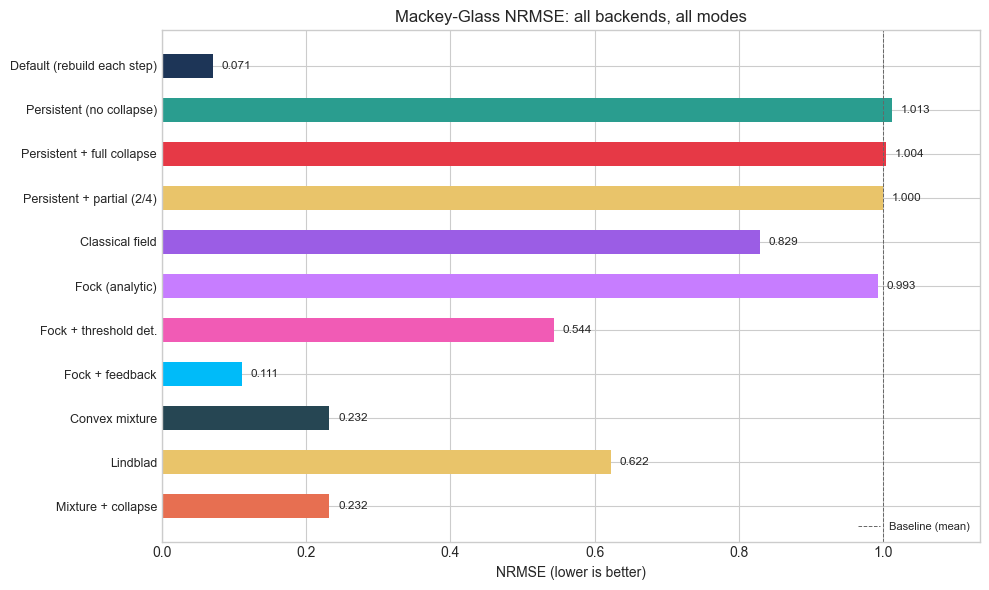

In [6]:
all_mg = qk_mg + pcv_mg + dq_mg
labels_mg = [l for l, s, _, _ in all_mg]
scores_mg = [s for _, s, _, _ in all_mg]
colors_mg = ['#1d3557', '#2a9d8f', '#e63946', '#e9c46a',
             '#9b5de5', '#c77dff', '#f15bb5', '#00bbf9',
             '#264653', '#e9c46a', '#e76f51']

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(labels_mg))
bars = ax.barh(y_pos, scores_mg, color=colors_mg, height=0.55)
ax.set_yticks(y_pos); ax.set_yticklabels(labels_mg, fontsize=9)
ax.set_xlabel('NRMSE (lower is better)')
ax.set_xlim(0, max(scores_mg) * 1.12)
ax.axvline(x=1.0, color='#666', ls='--', lw=0.7, label='Baseline (mean)')
for bar, score in zip(bars, scores_mg):
    ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=8.5)
ax.set_title('Mackey-Glass NRMSE: all backends, all modes')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## NARMA-10 — All Modes

NARMA-10 requires retaining 10 past inputs through a nonlinear recurrence — a harder task that stresses memory depth.

  Qiskit default: NRMSE=0.8072 (5.6s)
  Dynamiqs mixture: NRMSE=0.7516 (0.3s)
  Dynamiqs Lindblad: NRMSE=0.9775 (1.1s)
  Dynamiqs mixture+collapse: NRMSE=0.7516 (0.2s)
  Perceval field: NRMSE=1.0465 (0.7s)
  Perceval Fock analytic: NRMSE=1.0065 (22.5s)
  Perceval Fock threshold: NRMSE=0.9985 (35.7s)
  Perceval Fock feedback: NRMSE=0.9905 (18.8s)


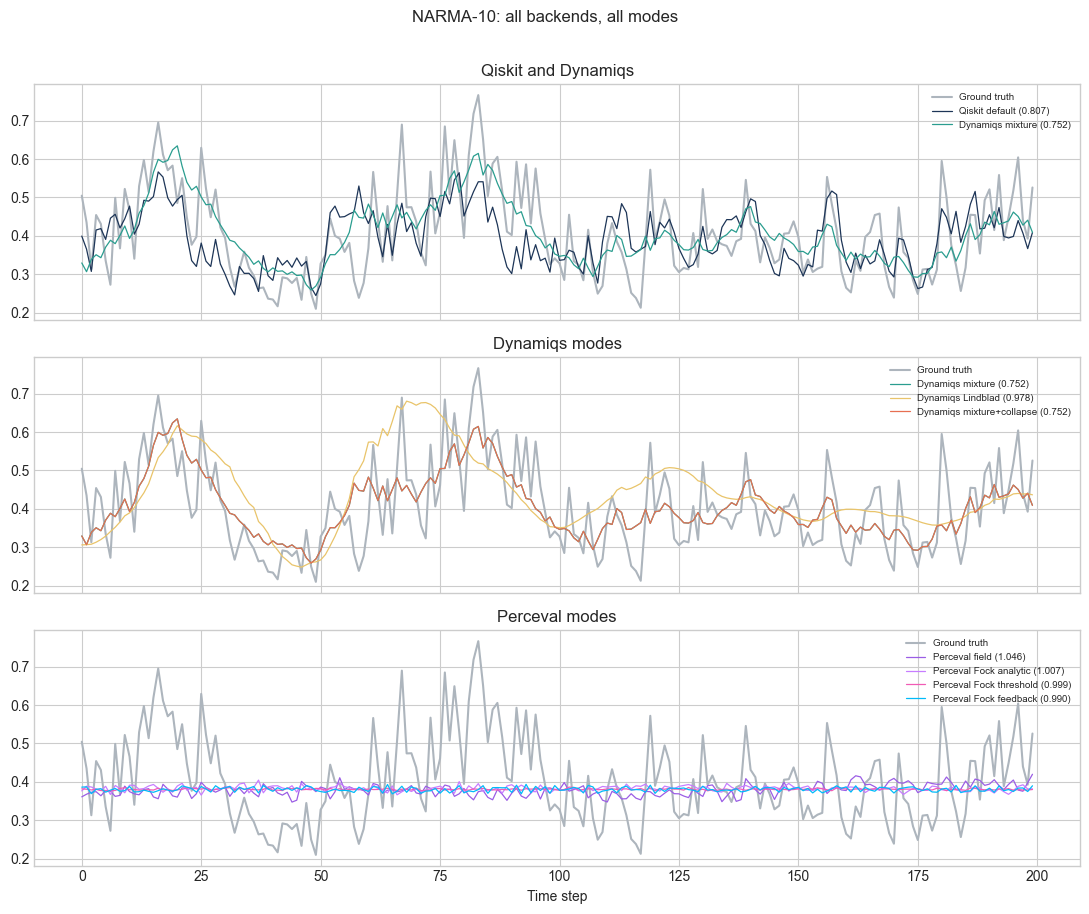

In [7]:
nm = []
nm.append(run_config('Qiskit default',
    QiskitBackend(n_qubits=4, depth=4, seed=11), 1e-3,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Dynamiqs mixture',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1, seed=3), 1e-5,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Dynamiqs Lindblad',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1, lindblad=True, seed=3), 1e-5,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Dynamiqs mixture+collapse',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1,
                    projective_measurement=True, seed=3), 1e-5,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Perceval field',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, memory_decay=0.95, seed=3), 1e-4,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Perceval Fock analytic',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    memory_decay=0.7, seed=3), 1e-1,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Perceval Fock threshold',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    threshold_detection=True, memory_decay=0.7,
                    n_detection_samples=2000, seed=3), 1e-1,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))
nm.append(run_config('Perceval Fock feedback',
    PercevalBackend(n_modes=5, n_photons=2, depth=2, fock_mode=True,
                    feedback=True, memory_decay=0.7, seed=3), 1e-1,
    X_nm_tr, y_nm_tr, X_nm_te, y_nm_te))

for l, s, _, t in nm:
    print(f'  {l}: NRMSE={s:.4f} ({t:.1f}s)')

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
ground_nm = y_nm_te[WASHOUT:]
n_plot = 200

ax = axes[0]
ax.plot(ground_nm[:n_plot], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip([nm[0], nm[1]], ['#1d3557', '#2a9d8f']):
    ax.plot(p[:n_plot], label=f'{l} ({s:.3f})', lw=0.9, color=c)
ax.set_title('Qiskit and Dynamiqs'); ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
ax.plot(ground_nm[:n_plot], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip([nm[1], nm[2], nm[3]], ['#2a9d8f', '#e9c46a', '#e76f51']):
    ax.plot(p[:n_plot], label=f'{l} ({s:.3f})', lw=0.9, color=c)
ax.set_title('Dynamiqs modes'); ax.legend(fontsize=7, loc='upper right')

ax = axes[2]
ax.plot(ground_nm[:n_plot], label='Ground truth', lw=1.5, color='#adb5bd')
for (l, s, p, _), c in zip([nm[4], nm[5], nm[6], nm[7]], ['#9b5de5', '#c77dff', '#f15bb5', '#00bbf9']):
    ax.plot(p[:n_plot], label=f'{l} ({s:.3f})', lw=0.9, color=c)
ax.set_title('Perceval modes'); ax.set_xlabel('Time step')
ax.legend(fontsize=7, loc='upper right')

fig.suptitle('NARMA-10: all backends, all modes', y=1.01)
plt.tight_layout(); plt.show()

## NARMA-10 Summary

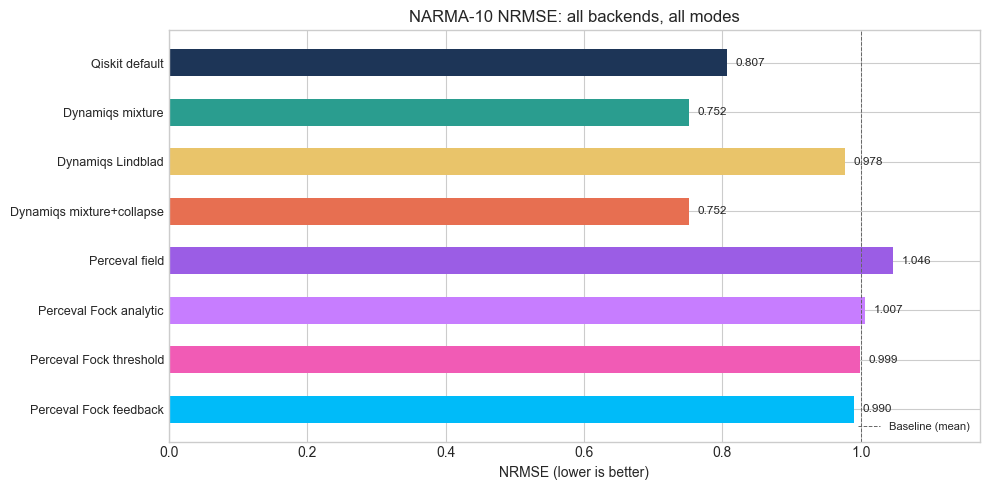

In [8]:
labels_nm = [l for l, s, _, _ in nm]
scores_nm = [s for _, s, _, _ in nm]
colors_nm = ['#1d3557', '#2a9d8f', '#e9c46a', '#e76f51',
             '#9b5de5', '#c77dff', '#f15bb5', '#00bbf9']

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(labels_nm))
bars = ax.barh(y_pos, scores_nm, color=colors_nm, height=0.55)
ax.set_yticks(y_pos); ax.set_yticklabels(labels_nm, fontsize=9)
ax.set_xlabel('NRMSE (lower is better)')
ax.set_xlim(0, max(scores_nm) * 1.12)
ax.axvline(x=1.0, color='#666', ls='--', lw=0.7, label='Baseline (mean)')
for bar, score in zip(bars, scores_nm):
    ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=8.5)
ax.set_title('NARMA-10 NRMSE: all backends, all modes')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Lorenz — 3D Multivariate Input

The 3-component Lorenz state vector is fed at each step; the target is x(t+1). Same `Reservoir` API, no code changes vs scalar tasks.

  Qiskit (5q, d3): NRMSE=0.2762 (5.6s)
  Dynamiqs (d=5): NRMSE=0.4615 (0.3s)


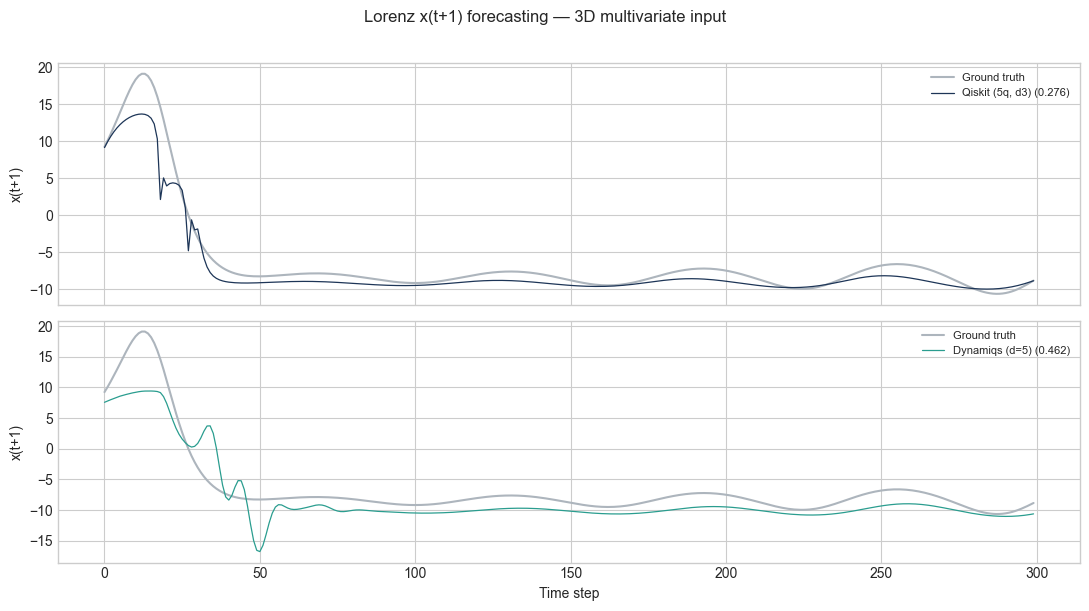

In [9]:
lz = []
lz.append(run_config('Qiskit (5q, d3)',
    QiskitBackend(n_qubits=5, depth=3, seed=5), 1e-3,
    X_lz_tr, y_lz_tr, X_lz_te, y_lz_te))
lz.append(run_config('Dynamiqs (d=5)',
    DynamiqsBackend(levels=5, dt=0.3, gamma=0.1, seed=3), 1e-5,
    X_lz_tr, y_lz_tr, X_lz_te, y_lz_te))

for l, s, _, t in lz:
    print(f'  {l}: NRMSE={s:.4f} ({t:.1f}s)')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ground_lz = y_lz_te[WASHOUT:]
for ax, (l, s, p, _), c in zip(axes, lz, ['#1d3557', '#2a9d8f']):
    ax.plot(ground_lz[:300], label='Ground truth', lw=1.5, color='#adb5bd')
    ax.plot(p[:300], label=f'{l} ({s:.3f})', lw=0.9, color=c)
    ax.set_ylabel('x(t+1)'); ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time step')
fig.suptitle('Lorenz x(t+1) forecasting — 3D multivariate input', y=1.01)
plt.tight_layout(); plt.show()

## Final Summary

In [10]:
print('=' * 70)
print(f"{'Configuration':<30} | {'MG':>8} | {'NARMA':>8} | {'Lorenz':>8}")
print('-' * 70)

rows = [
    ('Qiskit default',           qk_mg[0][1], nm[0][1],  lz[0][1]),
    ('Qiskit pers.+collapse',     qk_mg[2][1], None,      None),
    ('Qiskit pers.+partial',      qk_mg[3][1], None,      None),
    ('Perceval field',            pcv_mg[0][1], nm[4][1], None),
    ('Perceval Fock analytic',    pcv_mg[1][1], nm[5][1], None),
    ('Perceval Fock threshold',   pcv_mg[2][1], nm[6][1], None),
    ('Perceval Fock feedback',    pcv_mg[3][1], nm[7][1], None),
    ('Dynamiqs mixture',          dq_mg[0][1], nm[1][1],  lz[1][1]),
    ('Dynamiqs Lindblad',         dq_mg[1][1], nm[2][1],  None),
    ('Dynamiqs mixture+collapse', dq_mg[2][1], nm[3][1],  None),
]

for name, mg, narma, lorenz in rows:
    mg_s    = f'{mg:.4f}'     if mg     is not None else '---'
    nm_s    = f'{narma:.4f}'  if narma  is not None else '---'
    lz_s    = f'{lorenz:.4f}' if lorenz is not None else '---'
    print(f'{name:<30} | {mg_s:>8} | {nm_s:>8} | {lz_s:>8}')

print('=' * 70)

Configuration                  |       MG |    NARMA |   Lorenz
----------------------------------------------------------------------
Qiskit default                 |   0.0708 |   0.8072 |   0.2762
Qiskit pers.+collapse          |   1.0035 |      --- |      ---
Qiskit pers.+partial           |   0.9998 |      --- |      ---
Perceval field                 |   0.8289 |   1.0465 |      ---
Perceval Fock analytic         |   0.9929 |   1.0065 |      ---
Perceval Fock threshold        |   0.5438 |   0.9985 |      ---
Perceval Fock feedback         |   0.1106 |   0.9905 |      ---
Dynamiqs mixture               |   0.2323 |   0.7516 |   0.4615
Dynamiqs Lindblad              |   0.6222 |   0.9775 |      ---
Dynamiqs mixture+collapse      |   0.2323 |   0.7516 |      ---
